# 📚 LearnLog — 학습 습관 트래커 에이전트
### LangGraph 기반 교육/학습 에이전트 | PDCA 방식 단계별 구현

---

## 🔄 PDCA 진행 구조

| 단계 | 내용 |
|------|------|
| **Plan** | Step 1: 에이전트 설계 (목적, 기능, 그래프 구조) |
| **Do** | Step 2: 기본 구조 / Step 3: 핵심 기능 + interrupt() + MemorySaver |
| **Check** | 각 단계별 실행 테스트 |
| **Act** | 개선 방향 및 확장 아이디어 |

---
## 📋 Step 1: 에이전트 설계

### 🤖 에이전트 이름: LearnLog

### 🎯 목적
매일 기분과 학습 성취를 체크인하고, Notion에 일기로 자동 포스팅해주는  
**학습 습관 트래커 에이전트** (interrupt + MemorySaver 기반 지속 실행)

---

### ⚙️ 핵심 기능 3가지

1. **😊 기분 + 목표 체크**: 매일 기분을 물어보고, 기존 목표 유지 or 새 목표 추가/변경 선택
2. **✅ 학습 체크인 + 스트릭**: 오늘 학습 성취를 기록하고 연속 달성 일수 추적
3. **📔 Notion 일기 자동 포스팅**: 기분·성취·추천 자료를 묶어 Notion에 저장

---

### 🗺️ 그래프 구조 (Pattern 3: interrupt + MemorySaver)

```
START
  │
  ▼
[goal_check_node]        ← interrupt() : 기분 + 목표 유지 여부 동시 질문
  │
  ▼ [Conditional Edge 1]
  ├─ "setup" → [goal_setup_node]   ← 새 목표 추가/변경
  │                │
  └─ "skip" ───────┤  (목표 유지)
                   ▼
            [checkin_node]         ← interrupt() : 오늘 학습 내용 입력
                   │
                   ▼ [Conditional Edge 2]
                   ├─ "search" → [resource_search_node]  ← Tavily 검색
                   │                   │
                   └─ "write" ─────────┤
                                       ▼
                           [diary_writer_node]  ← 기분 + 성취 → 일기 작성
                                       │
                                       ▼
                           [notion_post_node]   ← Notion API 포스팅
                                       │
                                      END
```

**실행 흐름 (interrupt 기반 반복)**
```
[1일차]
invoke()             → goal_check_node ⏸️ 대기
Command(resume=답1)  → 기분/목표 분석 → checkin ⏸️ 대기
Command(resume=답2)  → 일기 작성 → Notion 포스팅 ✅

[2일차] 같은 thread_id로 invoke()
         → MemorySaver가 streak·goals 기억하고 이어서 실행
```

---

### 📦 State 설계

| 필드 | 타입 | 설명 |
|------|------|------|
| `messages` | `Annotated[list, add_messages]` | 대화 히스토리 |
| `learning_goals` | `List[str]` | 전체 목표 목록 (복수 지원) |
| `active_goal` | `str` | 오늘 활성 목표 |
| `mood` | `str` | **오늘 기분** ← NEW |
| `today_schedule` | `str` | 오늘 학습 일정 |
| `today_achievements` | `str` | 오늘 달성 내용 |
| `streak` | `int` | 연속 달성 일수 |
| `search_results` | `str` | Tavily 검색 결과 |
| `diary_content` | `str` | 생성된 일기 |
| `next_action` | `str` | 조건 분기용 (`"setup"/"skip"/"search"/"write"`) |

---
## 🔨 Step 2: 기본 구조 구현

### 📦 패키지 설치

### 🔑 환경변수 설정

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "your-openai-api-key")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "your-tavily-api-key")

NOTION_TOKEN       = os.getenv("NOTION_TOKEN",       "your-notion-token")
NOTION_DATABASE_ID = os.getenv("NOTION_DATABASE_ID", "your-database-id")

print("✅ 환경변수 로드 완료")

✅ 환경변수 로드 완료


### 📥 라이브러리 Import

In [5]:
import json
from typing import TypedDict, Annotated, List
from datetime import date

# LangGraph 핵심
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command       # ← Pattern 3 핵심
from langgraph.checkpoint.memory import MemorySaver # ← 상태 영구 보존

# LangChain
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain.chat_models import init_chat_model

print("✅ 라이브러리 Import 완료")
print("   - interrupt, Command : Human-in-the-loop")
print("   - MemorySaver        : streak·goals 상태 보존")

✅ 라이브러리 Import 완료
   - interrupt, Command : Human-in-the-loop
   - MemorySaver        : streak·goals 상태 보존


### 🗂️ State 정의

In [6]:
class LearnLogState(TypedDict):
    """LearnLog 에이전트 상태"""
    messages:           Annotated[list, add_messages]  # 대화 히스토리
    learning_goals:     List[str]                      # 전체 목표 목록 (복수 지원)
    active_goal:        str                            # 오늘 활성 목표
    mood:               str                            # 오늘 기분 ← NEW
    today_achievements: str                            # 오늘 성취
    streak:             int                            # 연속 달성 일수
    search_results:     str                            # 검색 결과
    diary_content:      str                            # 생성된 일기
    next_action:        str                            # 조건 분기용

print("✅ LearnLogState 정의 완료")
print("   변경: learning_goal → learning_goals (List), active_goal")
print("   신규: mood (오늘 기분)")

✅ LearnLogState 정의 완료
   변경: learning_goal → learning_goals (List), active_goal
   신규: mood (오늘 기분)


### 🤖 LLM 초기화

In [7]:
llm = init_chat_model("openai:gpt-4o-mini")
print("✅ LLM 초기화 완료 (gpt-4o-mini)")

✅ LLM 초기화 완료 (gpt-4o-mini)


In [8]:
# ── 공통 헬퍼 함수 ──────────────────────────────────────────
def get_active_goal(state: LearnLogState) -> str:
    """active_goal이 없으면 learning_goals[0]으로 폴백"""
    return state.get("active_goal") or (state.get("learning_goals") or [""])[0]

print("✅ get_active_goal 헬퍼 정의 완료")

✅ get_active_goal 헬퍼 정의 완료


---
### 🔹 노드 A (Step 2): goal_setup_node

> Step 2 기본 그래프에서 START에 직접 연결되는 노드입니다.

In [12]:
def goal_setup_node(state: LearnLogState) -> dict:
    """
    노드: 새 학습 목표 설정 or 기존 목표에 추가
    Step 3에서는 goal_check_node가 'setup'으로 분기한 경우에만 실행
    goal_text는 goal_check_node에서 LLM이 추출해 active_goal에 저장
    """
    existing_goals = state.get("learning_goals", [])
    new_goal       = state.get("active_goal", "")

    system_prompt = f"""당신은 학습 코치 LearnLog입니다.
사용자의 새 학습 목표를 확인하고, 매일 실천 가능한 습관 3가지로 분해해주세요.

새 학습 목표: {new_goal}
기존 목표: {existing_goals if existing_goals else '없음'}

출력 형식:
🎯 목표 목록: [목표1, 목표2, ...]
📋 일일 습관:
  1. [습관] (XX분)
  2. [습관] (XX분)
  3. [습관] (XX분)

마지막에 체크인 준비가 됐는지 물어보세요."""

    response      = llm.invoke([SystemMessage(content=system_prompt)])
    updated_goals = existing_goals + [new_goal] if new_goal else existing_goals

    return {
        "messages":      [response],
        "learning_goals": updated_goals,
        "active_goal":   new_goal or (existing_goals[0] if existing_goals else ""),
    }

print("✅ goal_setup_node 정의 완료 (active_goal 기반으로 개선)")

✅ goal_setup_node 정의 완료 (active_goal 기반으로 개선)


### 🔹 노드 B (Step 2): checkin_node (기본 버전)

> Step 2에서는 interrupt() 없이 동작합니다. Step 3에서 interrupt() 버전으로 교체합니다.

In [13]:
def checkin_node_basic(state: LearnLogState) -> dict:
    """Step 2 기본 버전: interrupt 없이 messages에서 입력 추출"""
    system_prompt = """당신은 학습 습관 트래커 LearnLog입니다.
오늘의 학습 내용을 따뜻하게 정리하고, 스트릭을 언급하며 격려해주세요."""

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = llm.invoke(messages)

    last_human = next(
        (m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), ""
    )
    search_keywords = ["검색", "자료", "찾아", "추천"]
    needs_search    = any(kw in last_human for kw in search_keywords)

    return {
        "messages":          [response],
        "today_achievements": last_human,
        "streak":            state.get("streak", 0) + 1,
        "next_action":       "search" if needs_search else "write",
    }

print("✅ checkin_node_basic 정의 완료 (Step 2 전용)")

✅ checkin_node_basic 정의 완료 (Step 2 전용)


### 🔗 Step 2: 기본 그래프 (2개 노드)

In [14]:
basic_builder = StateGraph(LearnLogState)

basic_builder.add_node("goal_setup", goal_setup_node)
basic_builder.add_node("checkin",    checkin_node_basic)

basic_builder.add_edge(START,        "goal_setup")
basic_builder.add_edge("goal_setup", "checkin")
basic_builder.add_edge("checkin",    END)

basic_graph = basic_builder.compile()

print("✅ Step 2 기본 그래프 컴파일 완료")
print("구조: START → goal_setup → checkin → END")

✅ Step 2 기본 그래프 컴파일 완료
구조: START → goal_setup → checkin → END


### ▶️ Step 2 테스트

In [15]:
result = basic_graph.invoke({
    "messages":           [HumanMessage(content="LangGraph를 배우고 싶어요!")],
    "learning_goals":     [],
    "active_goal":        "",
    "mood":               "",
    "today_achievements": "",
    "streak":             0,
    "search_results":     "",
    "diary_content":      "",
    "next_action":        "",
})

print("=" * 60)
for msg in result["messages"]:
    role = "👤" if isinstance(msg, HumanMessage) else "🤖"
    print(f"{role} {msg.content}\n")
print("=" * 60)

👤 LangGraph를 배우고 싶어요!

🤖 🎯 목표 목록: [새로운 언어 배우기, 독서 습관 기르기, 운동 루틴 만들기]

📋 일일 습관:
  1. 새로운 언어 어휘 학습 (15분)
  2. 하루 10 페이지 독서 (20분)
  3. 간단한 스트레칭 또는 운동 (15분)

체크인 준비가 되셨나요?

🤖 오늘 LangGraph를 배우기로 결심하셨다니 정말 멋진 선택입니다! 🌟 새로운 언어를 배우는 것은 언제나 흥미로운 여정이죠. 

지금까지의 학습 내용을 정리해보면, 분명 의미 있는 시간을 보냈을 거라 생각합니다. 여러 언어의 구조를 이해하게 되고, 그것이 새로운 창의적인 사고를 여는 데 얼마나 도움이 되는지 느끼실 거예요. 

현재 여러분의 학습 스트릭이 계속 이어지고 있다면, 그 성과를 자랑스럽게 생각해 주세요! 지속적으로 이 여정을 즐기시고, 매일 조금씩 나아가는 자신을 응원해 주세요. 여러분의 꾸준함과 열정이 분명 큰 결과로 이어질 것입니다. 

내일은 어떤 언어를 더 탐구해볼까요? 계속해서 화이팅입니다! 💪📚✨



---
## 🚀 Step 3: 핵심 기능 추가

### 변경 사항
| | Step 2 | Step 3 |
|---|---|---|
| 노드 수 | 2개 | **6개** |
| Conditional Edge | 0개 | **2개** |
| Human-in-the-loop | ❌ | **interrupt()** |
| 상태 지속성 | ❌ | **MemorySaver** |
| 기분 추적 | ❌ | **mood 필드** |
| Tools | 0개 | **Tavily + Notion** |

### 🔧 Tool 1: Tavily 웹 검색

In [17]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(max_results=3)
print("✅ Tavily 검색 툴 초기화 완료")

✅ Tavily 검색 툴 초기화 완료


### 🔧 Tool 2: Notion API 커스텀 툴 (mood 파라미터 추가)

**Notion DB 속성**: `Title`, `Date`, `학습 목표`, `기분`, `스트릭`

In [18]:
from langchain_core.tools import tool
import requests

@tool
def post_to_notion(diary_content: str, learning_goal: str, mood: str, streak: int) -> str:
    """
    오늘의 학습 일기를 Notion 데이터베이스에 포스팅합니다.

    Args:
        diary_content: 일기 본문
        learning_goal: 오늘 활성 목표
        mood: 오늘 기분  ← NEW
        streak: 연속 달성 일수
    """
    headers = {
        "Authorization": f"Bearer {NOTION_TOKEN}",
        "Content-Type": "application/json",
        "Notion-Version": "2022-06-28",
    }
    today = date.today().isoformat()

    payload = {
        "parent": {"database_id": NOTION_DATABASE_ID},
        "properties": {
            "Title":    {"title":     [{"text": {"content": f"📔 {today} 학습 일기"}}]},
            "Date":     {"date":      {"start": today}},
            "학습 목표": {"rich_text": [{"text": {"content": learning_goal[:200]}}]},
            "기분":     {"rich_text": [{"text": {"content": mood[:100]}}]},  # ← NEW
            "스트릭":   {"number":    streak},
        },
        "children": [{
            "object": "block", "type": "paragraph",
            "paragraph": {"rich_text": [{"type": "text", "text": {"content": diary_content[:2000]}}]}
        }],
    }

    try:
        res = requests.post(
            "https://api.notion.com/v1/pages",
            headers=headers, json=payload, timeout=10
        )
        if res.status_code == 200:
            return f"✅ Notion 포스팅 성공! {res.json().get('url', '')}"
        return f"⚠️ 오류 ({res.status_code}): {res.text[:200]}"
    except Exception as e:
        return f"❌ 연결 오류: {e}"

print("✅ Notion 커스텀 툴 정의 완료 (mood 파라미터 추가)")

✅ Notion 커스텀 툴 정의 완료 (mood 파라미터 추가)


---
### 🔹 노드 1: goal_check_node ← NEW

**핵심**: `interrupt()`로 그래프를 멈추고 두 가지를 동시에 질문
- 😊 오늘 기분이 어때요?
- 🎯 기존 목표 계속할까요, 새로 추가/변경할까요?

```
invoke() 실행 → goal_check_node 도달 → interrupt() 호출
              → 그래프 ⏸️ 일시정지
              → 사용자가 Command(resume="답변") 전송
              → interrupt()가 "답변"을 반환하며 ▶️ 재개
```

In [19]:
def goal_check_node(state: LearnLogState) -> dict:
    """
    노드 1: 기분 체크 + 목표 유지/변경 의향 파악
    interrupt()로 사용자 입력을 기다립니다.
    """
    existing_goals = state.get("learning_goals", [])
    streak         = state.get("streak", 0)

    # ── 질문 메시지 구성 ──────────────────────────────────────
    if existing_goals:
        goals_str = ", ".join(f"'{g}'" for g in existing_goals)
        question = (
            f"안녕하세요! 🎉 {streak}일 연속 달성 중이에요!\n"
            f"현재 목표: [{goals_str}]\n\n"
            f"① 오늘 기분이 어떠세요?\n"
            f"② 기존 목표를 계속할까요, 아니면 새로 추가/변경할까요?\n"
            f"   (예: '기분 좋아요, 계속할게요' / '조금 지쳐요, 새 목표 추가하고 싶어요')"
        )
    else:
        question = (
            f"LearnLog에 오신 걸 환영해요! 📚\n\n"
            f"① 오늘 기분이 어떠세요?\n"
            f"② 어떤 학습 목표가 있으신가요?"
        )

    # ── interrupt(): 그래프 일시정지 → 사용자 입력 대기 ─────────
    user_response = interrupt(question)

    # ── LLM으로 기분, 목표 의향, 목표 텍스트 분석 ──────────────────
    analysis_prompt = f"""사용자 응답: "{user_response}"

아래 JSON 형식으로 분석해주세요:
{{
  "mood": "오늘 기분을 따뜻한 한 문장으로 요약",
  "wants_new_goal": true 또는 false,
  "goal_text": "사용자가 언급한 학습 목표만 추출 (없으면 null)"
}}

판단 기준:
- '새로운', '추가', '바꾸', '변경', '다른 목표' 언급 → wants_new_goal: true
- '계속', '유지', '그대로', 특별한 변경 요청 없음    → wants_new_goal: false
- 기존 목표가 아예 없는 경우                          → wants_new_goal: true

JSON만 응답해주세요. 다른 텍스트 없이."""

    analysis = llm.invoke([HumanMessage(content=analysis_prompt)])

    try:
        raw    = analysis.content.strip().removeprefix("```json").removesuffix("```").strip()
        parsed = json.loads(raw)
        mood      = parsed.get("mood", user_response[:50])
        wants_new = parsed.get("wants_new_goal", not bool(existing_goals))
        goal_text = parsed.get("goal_text") or ""
    except Exception:
        # 파싱 실패 시 키워드 기반 fallback
        change_kw = ["새로", "추가", "변경", "바꾸", "다른"]
        wants_new = any(kw in user_response for kw in change_kw) or not existing_goals
        mood      = user_response[:50]
        goal_text = ""

    next_action = "setup" if wants_new else "skip"
    print(f"😊 기분: {mood}")
    print(f"🎯 추출된 목표: {goal_text}")
    print(f"🔀 {'새 목표 설정으로 이동' if wants_new else f'기존 목표 유지: {existing_goals}'}")

    return {
        "messages":    [HumanMessage(content=user_response)],
        "mood":         mood,
        "active_goal":  goal_text,
        "next_action":  next_action,
    }

print("✅ goal_check_node 정의 완료")
print("   interrupt() → 기분 + 목표 의향 동시 질문")

✅ goal_check_node 정의 완료
   interrupt() → 기분 + 목표 의향 동시 질문


### 🔹 노드 3: checkin_node (interrupt 버전)

In [20]:
def checkin_node(state: LearnLogState) -> dict:
    """
    노드 3: 오늘 학습 체크인 (interrupt() 버전)
    두 번째 interrupt() 포인트
    """
    streak      = state.get("streak", 0)
    active_goal = get_active_goal(state)

    question = (
        f"🔥 {streak}일 연속 달성 중!\n"
        f"오늘 목표: {active_goal}\n\n"
        f"오늘 어떤 학습을 하셨나요? 자유롭게 말씀해주세요 😊\n"
        f"(관련 자료가 필요하면 '자료 찾아줘' 또는 '검색해줘'를 포함해주세요)"
    )

    # ── interrupt(): 두 번째 일시정지 ────────────────────────
    user_input = interrupt(question)

    search_keywords = ["검색", "자료", "찾아", "추천", "알려",
                       "search", "find", "resource", "recommend", "look up"]
    needs_search    = any(kw in user_input.lower() for kw in search_keywords)

    return {
        "messages":          [HumanMessage(content=user_input)],
        "today_achievements": user_input,
        "streak":            streak + 1,
        "next_action":       "search" if needs_search else "write",
    }

print("✅ checkin_node (interrupt 버전) 정의 완료")

✅ checkin_node (interrupt 버전) 정의 완료


### 🔹 노드 4: resource_search_node — Tavily 검색

In [ ]:
def resource_search_node(state: LearnLogState) -> dict:
    """노드 4: Tavily로 학습 자료 검색 (Tool 연동)"""
    goal         = get_active_goal(state)
    achievements = state.get("today_achievements", "")
    query        = f"{goal} {achievements} 학습 자료".strip()
    print(f"🔍 검색 중: {query}")

    try:
        results = tavily_search.invoke(query)
        if isinstance(results, str):
            formatted = results
        else:
            formatted = "\n".join([
                f"📌 {r.get('title', '')}\n   🔗 {r.get('url', '')}\n   {r.get('content', '')[:120]}..."
                for r in results
            ])
    except Exception as e:
        error_msg = f"검색 중 오류가 발생했어요: {e}\n직접 검색해보시는 걸 추천드려요 🙏"
        return {"messages": [AIMessage(content=error_msg)], "search_results": ""}

    response = llm.invoke([SystemMessage(
        content=f"학습 목표: {goal}\n오늘 학습 내용: {achievements}\n\n검색 결과:\n{formatted}\n\n자료를 친절하게 소개해주세요."
    )])

    return {"messages": [response], "search_results": formatted}

print("✅ resource_search_node 정의 완료")

### 🔹 노드 5: diary_writer_node — 기분 포함 일기 작성

In [24]:
def diary_writer_node(state: LearnLogState) -> dict:
    """노드 5: 기분 + 성취를 묶어 일기 작성 (검색 자료는 채팅 메시지로만 제공)"""
    today        = date.today().strftime("%Y년 %m월 %d일")
    mood         = state.get("mood", "") or "평온한 하루"
    goal         = get_active_goal(state)
    achievements = state.get("today_achievements", "") or "오늘의 학습을 기록하지 않았어요"
    streak       = state.get("streak", 0)

    prompt = f"""오늘의 학습 일기를 작성해주세요.

날짜: {today}
오늘 기분: {mood}    ← 일기에 자연스럽게 녹여주세요
학습 목표: {goal}
오늘 성취: {achievements}
연속 달성: {streak}일

아래 형식으로 써주세요:

---
📅 {today}
😊 오늘의 기분: [기분을 감성적으로 한 문장]
🎯 목표: [목표 요약]

✅ 오늘의 학습:
[오늘 한 내용 구체적으로]

💭 회고:
[배운 점, 느낀 점 2-3문장]

🔥 스트릭: {streak}일 연속 달성!

🌱 내일 계획:
[내일 할 일 1-2가지]
---

따뜻한 격려 메시지로 마무리해주세요."""

    response = llm.invoke([SystemMessage(content=prompt)])
    return {"messages": [response], "diary_content": response.content}

print("✅ diary_writer_node 정의 완료")

✅ diary_writer_node 정의 완료


### 🔹 노드 6: notion_post_node — Notion 포스팅

In [25]:
def notion_post_node(state: LearnLogState) -> dict:
    """노드 6: 일기를 Notion에 포스팅"""
    diary  = state.get("diary_content", "")
    goal   = get_active_goal(state)
    mood   = state.get("mood", "") or "평온한 하루"
    streak = state.get("streak", 0)

    # 포인트 1: diary_content 빈 값 guard
    if not diary:
        return {"messages": [AIMessage(content="일기 내용이 없어서 Notion 저장을 건너뛰었어요.")]}

    result = post_to_notion.invoke({
        "diary_content": diary,
        "learning_goal": goal,
        "mood":          mood,
        "streak":        streak,
    })

    # 포인트 2: 성공/실패에 따라 메시지 분기
    if result.startswith("✅"):
        final = (
            f"📔 오늘의 학습 일기가 Notion에 저장됐어요!\n\n"
            f"{result}\n\n"
            f"오늘 기분 [{mood}] 이었는데도 공부하셨군요! 🌟\n"
            f"{streak}일 연속 달성 중이에요. 내일도 화이팅! 💪"
        )
    else:
        final = (
            f"⚠️ Notion 저장에 실패했어요.\n\n"
            f"{result}\n\n"
            f"오늘 학습은 정말 수고하셨어요! 🌟\n"
            f"내일 다시 시도해봐요. 화이팅! 💪"
        )
    return {"messages": [AIMessage(content=final)]}

print("✅ notion_post_node 정의 완료")

✅ notion_post_node 정의 완료


---
### 🔀 Conditional Edge 함수 2개

In [26]:
def route_after_goal_check(state: LearnLogState) -> str:
    """
    Conditional Edge 1: goal_check 이후
    'setup' → goal_setup_node  (새 목표)
    'skip'  → checkin_node     (기존 목표 유지)
    """
    return state.get("next_action", "skip")


def route_after_checkin(state: LearnLogState) -> str:
    """
    Conditional Edge 2: checkin 이후
    'search' → resource_search_node
    'write'  → diary_writer_node
    """
    return state.get("next_action", "write")


print("✅ Conditional Edge 함수 2개 정의 완료")

✅ Conditional Edge 함수 2개 정의 완료


---
### 🔗 Step 3: 전체 그래프 + MemorySaver 컴파일

In [27]:
builder = StateGraph(LearnLogState)

# ── 노드 6개 등록 ────────────────────────────────────────────
builder.add_node("goal_check",      goal_check_node)      # 1: 기분+목표 확인
builder.add_node("goal_setup",      goal_setup_node)      # 2: 새 목표 설정
builder.add_node("checkin",         checkin_node)          # 3: 오늘 체크인
builder.add_node("resource_search", resource_search_node)  # 4: 자료 검색
builder.add_node("diary_writer",    diary_writer_node)     # 5: 일기 작성
builder.add_node("notion_post",     notion_post_node)      # 6: Notion 포스팅

# ── 엣지 연결 ────────────────────────────────────────────────
builder.add_edge(START, "goal_check")

# Conditional Edge 1: goal_check 이후 분기
builder.add_conditional_edges(
    "goal_check",
    route_after_goal_check,
    {
        "setup": "goal_setup",  # 새 목표 설정
        "skip":  "checkin",     # 기존 목표 유지 → 바로 체크인
    }
)

builder.add_edge("goal_setup", "checkin")

# Conditional Edge 2: checkin 이후 분기
builder.add_conditional_edges(
    "checkin",
    route_after_checkin,
    {
        "search": "resource_search",
        "write":  "diary_writer",
    }
)

builder.add_edge("resource_search", "diary_writer")
builder.add_edge("diary_writer",    "notion_post")
builder.add_edge("notion_post",     END)

# ── MemorySaver: thread_id별 상태 영구 보존 ───────────────────
memory         = MemorySaver()
learnlog_graph = builder.compile(checkpointer=memory)

print("✅ LearnLog 전체 그래프 컴파일 완료!")
print()
print("노드 6개  /  Conditional Edge 2개  /  MemorySaver 활성")
print()
print("흐름:")
print("START → goal_check(interrupt) → [CE1]")
print("          ├─ setup → goal_setup → checkin(interrupt) → [CE2]")
print("          └─ skip  ──────────→ checkin(interrupt) → [CE2]")
print("                                  ├─ search → resource_search → diary_writer → notion_post")
print("                                  └─ write  ─────────────────→ diary_writer → notion_post")

✅ LearnLog 전체 그래프 컴파일 완료!

노드 6개  /  Conditional Edge 2개  /  MemorySaver 활성

흐름:
START → goal_check(interrupt) → [CE1]
          ├─ setup → goal_setup → checkin(interrupt) → [CE2]
          └─ skip  ──────────→ checkin(interrupt) → [CE2]
                                  ├─ search → resource_search → diary_writer → notion_post
                                  └─ write  ─────────────────→ diary_writer → notion_post


### 📊 그래프 시각화

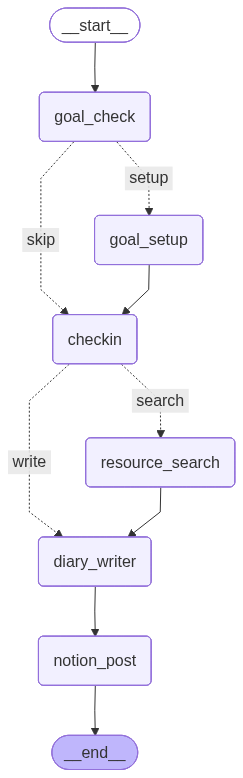

In [28]:
try:
    from IPython.display import Image, display
    display(Image(learnlog_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"시각화 패키지 필요 (선택사항): {e}")
    print(learnlog_graph.get_graph().draw_mermaid())

---
### ▶️ Step 3 실행 테스트 — interrupt() + Command(resume=...)

```
실행 순서:
1. invoke(initial_state)     → goal_check_node interrupt ⏸️
2. Command(resume=답변1)     → 기분/목표 분석 → checkin interrupt ⏸️
3. Command(resume=답변2)     → 일기 작성 → Notion 포스팅 ✅
4. [다음 날] invoke()        → MemorySaver가 streak·goals 이어받음
```

In [29]:
# thread_id: 같은 ID면 MemorySaver가 이전 상태를 기억
config = {"configurable": {"thread_id": "kay"}}

# ── 1️⃣ 첫 번째 실행 ─────────────────────────────────────────
print("1️⃣ 첫 실행 시작 → goal_check_node interrupt 대기 중...\n")

initial_state = {
    "messages":           [],
    "learning_goals":     [],
    "active_goal":        "",
    "mood":               "",
    "today_achievements": "",
    "streak":             0,
    "search_results":     "",
    "diary_content":      "",
    "next_action":        "",
}

result = learnlog_graph.invoke(initial_state, config=config)

# interrupt 상태 확인
snap = learnlog_graph.get_state(config)
print(f"⏸️  대기 중인 노드: {snap.next}")
if snap.tasks:
    for task in snap.tasks:
        if hasattr(task, 'interrupts') and task.interrupts:
            print(f"\n🤖 LearnLog 질문:\n{task.interrupts[0].value}")

1️⃣ 첫 실행 시작 → goal_check_node interrupt 대기 중...

⏸️  대기 중인 노드: ('goal_check',)

🤖 LearnLog 질문:
LearnLog에 오신 걸 환영해요! 📚

① 오늘 기분이 어떠세요?
② 어떤 학습 목표가 있으신가요?


In [30]:
# ── 2️⃣ 사용자 답변 1: 기분 + 목표 의향 ────────────────────────
print("2️⃣ 기분 + 목표 답변 입력\n")

answer_1 = "오늘 기분 좋아요! 😊 LangGraph 공부를 새로 시작하고 싶어요"
print(f"👤 사용자: {answer_1}\n")

learnlog_graph.invoke(Command(resume=answer_1), config=config)

# 상태 확인
snap = learnlog_graph.get_state(config)
print(f"\n😊 기록된 기분: {snap.values.get('mood')}")
print(f"🎯 목표 목록:   {snap.values.get('learning_goals')}")
print(f"🔀 다음 노드:   {snap.next}")
if snap.tasks:
    for task in snap.tasks:
        if hasattr(task, 'interrupts') and task.interrupts:
            print(f"\n🤖 LearnLog 질문:\n{task.interrupts[0].value}")

2️⃣ 기분 + 목표 답변 입력

👤 사용자: 오늘 기분 좋아요! 😊 LangGraph 공부를 새로 시작하고 싶어요

😊 기분: 오늘 기분이 좋고 긍정적입니다.
🎯 추출된 목표: LangGraph 공부
🔀 새 목표 설정으로 이동

😊 기록된 기분: 오늘 기분이 좋고 긍정적입니다.
🎯 목표 목록:   ['LangGraph 공부']
🔀 다음 노드:   ('checkin',)

🤖 LearnLog 질문:
🔥 0일 연속 달성 중!
오늘 목표: LangGraph 공부

오늘 어떤 학습을 하셨나요? 자유롭게 말씀해주세요 😊
(관련 자료가 필요하면 '자료 찾아줘' 또는 '검색해줘'를 포함해주세요)


In [31]:
# ── 3️⃣ 사용자 답변 2: 오늘 학습 체크인 ────────────────────────
print("3️⃣ 오늘 학습 체크인 입력 → 일기 작성 → Notion 포스팅\n")

answer_2 = "LangGraph의 interrupt()와 Command(resume)을 공부했어요! 관련 자료도 찾아주세요"
print(f"👤 사용자: {answer_2}\n")

final = learnlog_graph.invoke(Command(resume=answer_2), config=config)

print("\n" + "="*60)
print("📔 생성된 일기:")
print("="*60)
print(final.get("diary_content", ""))
print("="*60)
print(f"\n🔥 스트릭:    {final.get('streak')}일")
print(f"😊 기분:      {final.get('mood')}")
print(f"🎯 목표:      {final.get('learning_goals')}")

3️⃣ 오늘 학습 체크인 입력 → 일기 작성 → Notion 포스팅

👤 사용자: LangGraph의 interrupt()와 Command(resume)을 공부했어요! 관련 자료도 찾아주세요

🔍 검색 중: LangGraph 공부 LangGraph의 interrupt()와 Command(resume)을 공부했어요! 관련 자료도 찾아주세요 학습 자료

📔 생성된 일기:
---
📅 2026년 05월 10일  
😊 오늘의 기분: 오늘은 마음이 따뜻해지고 긍정적인 에너지가 넘치는 하루였습니다.  
🎯 목표: LangGraph 공부  

✅ 오늘의 학습:  
LangGraph의 interrupt()와 Command(resume)을 집중적으로 학습했습니다. interrupt() 메서드의 기능을 통해 프로세스를 중단하고, 그 후 Command(resume)을 사용해 다시 실행하는 과정은 매우 흥미로웠습니다. 관련 자료를 찾아보며 다양한 활용 사례도 접해보았어요. 오늘 이 두 개념에 대한 이해가 깊어졌습니다.  

💭 회고:  
LangGraph의 이 두 메서드는 실질적으로 어떻게 프로그램의 흐름을 제어하는지를 명확히 깨달을 수 있었어요. 앞으로의 개발에서도 이러한 메서드를 잘 활용하여 더 유연한 프로그래밍을 할 수 있을 것 같아 기대가 됩니다.  

🔥 스트릭: 1일 연속 달성!  

🌱 내일 계획:  
LangGraph의 다른 메서드들, 특히 state 관리와 관련된 기능에 대해 학습할 예정입니다. 또, 개인 프로젝트에 LangGraph를 활용해보기 위해 미리 구상해볼 계획입니다.  

당신의 열정과 노력은 정말 대단합니다! 앞으로도 긍정적인 마음으로 학습을 이어가길 응원합니다. 😊✨

🔥 스트릭:    1일
😊 기분:      오늘 기분이 좋고 긍정적입니다.
🎯 목표:      ['LangGraph 공부']


In [32]:
# ── 4️⃣ 다음 날 실행: MemorySaver가 streak·goals 이어받음 ─────
print("4️⃣ [다음 날] 같은 thread_id로 재실행\n")

# 오늘자 초기화 필드만 전달 (streak·learning_goals는 MemorySaver가 복원)
next_day = {
    "messages":           [],
    "mood":               "",
    "today_achievements": "",
    "search_results":     "",
    "diary_content":      "",
    "next_action":        "",
}

learnlog_graph.invoke(next_day, config=config)

snap2 = learnlog_graph.get_state(config)
print("💾 MemorySaver가 기억하는 상태:")
print(f"   🎯 목표:   {snap2.values.get('learning_goals')}")
print(f"   🔥 스트릭: {snap2.values.get('streak')}일  ← 이어받음!")
if snap2.tasks:
    for task in snap2.tasks:
        if hasattr(task, 'interrupts') and task.interrupts:
            print(f"\n🤖 LearnLog (기존 목표 기억한 버전):")
            print(task.interrupts[0].value)

4️⃣ [다음 날] 같은 thread_id로 재실행

💾 MemorySaver가 기억하는 상태:
   🎯 목표:   ['LangGraph 공부']
   🔥 스트릭: 1일  ← 이어받음!

🤖 LearnLog (기존 목표 기억한 버전):
안녕하세요! 🎉 1일 연속 달성 중이에요!
현재 목표: ['LangGraph 공부']

① 오늘 기분이 어떠세요?
② 기존 목표를 계속할까요, 아니면 새로 추가/변경할까요?
   (예: '기분 좋아요, 계속할게요' / '조금 지쳐요, 새 목표 추가하고 싶어요')


---
## 🔄 Act: 개선 방향 & 확장 아이디어

### 현재 구현 완료 ✅

| 요구사항 | 상태 |
|---------|------|
| LangGraph 사용 | ✅ |
| 최소 3개 노드 (6개 구현) | ✅ |
| Conditional Edge 2개 | ✅ |
| Tool 2개 (Tavily + Notion) | ✅ |
| interrupt() Human-in-the-loop | ✅ |
| MemorySaver 상태 영구 보존 | ✅ |
| mood 기분 추적 + 일기·Notion 반영 | ✅ |

### 선택 기능 확장 💡

**1. SqliteSaver — 앱 재시작 후에도 상태 유지**
```python
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver.from_conn_string("learnlog.db")
graph  = builder.compile(checkpointer=memory)
```

**2. 병렬 실행 (Send API) — 복수 목표 동시 검색**
```python
from langgraph.types import Send
def fan_out(state):
    return [Send("resource_search", {"active_goal": g})
            for g in state["learning_goals"]]
```

**3. 기분 트렌드 분석 노드 — mood 히스토리 기반 번아웃 감지**

**4. 주간 리포트 — 7일치 기분·스트릭 Notion 주간 요약 자동 포스팅**

---
## 📌 전체 구조 요약

```
[Pattern 3: interrupt() + MemorySaver]

invoke()         ──▶  goal_check_node
                       └ interrupt() ⏸️  "오늘 기분은? 목표 유지?"
Command(resume)  ──▶  기분 분석 → [Conditional Edge 1]
                         ├─ setup → goal_setup → checkin
                         └─ skip  ──────────── → checkin
                                                  └ interrupt() ⏸️  "오늘 학습은?"
Command(resume)  ──▶  [Conditional Edge 2]
                         ├─ search → resource_search → diary_writer → notion_post → END
                         └─ write  ────────────────── → diary_writer → notion_post → END

💾 MemorySaver: thread_id별 streak·goals·mood 자동 저장
   → 다음 날 같은 thread_id로 invoke() → 상태 이어받음
```

**State 주요 필드**
| 필드 | 용도 |
|------|------|
| `mood` | goal_check에서 수집 → diary·Notion에 반영 |
| `learning_goals` | List로 복수 목표 관리 |
| `streak` | MemorySaver로 날마다 누적 |

**Tools**
- 🔍 `TavilySearchResults` — 실시간 학습 자료 검색
- 📔 `post_to_notion` — 기분 포함 일기를 Notion에 저장